# results: Fairness and bias in LMs over time


In [2]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr, pearsonr, linregress

In [3]:
# paths
OUT_DIR = "results_fairness_over_time"
SUMMARY_CSV = os.path.join(OUT_DIR, "summary_all_models.csv")
GROUPS_CSV  = os.path.join(OUT_DIR, "groups_all_models.csv")

df_sum = pd.read_csv(SUMMARY_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)
df_groups = pd.read_csv(GROUPS_CSV).sort_values(["year", "model_id", "group"]).reset_index(drop=True)

# df_sum.head(), df_groups.head()
# clean model_id strings
df_sum["model_id"] = df_sum["model_id"].astype(str).str.strip()
df_groups["model_id"] = df_groups["model_id"].astype(str).str.strip()

# exclude the non-base models
exclude_models = [
    "LiquidAI/LFM2-2.6B",
    "Salesforce/xLAM-2-3b-fc-r",
    "bigscience/bloomz-3b",
]
exclude_models = [m.strip() for m in exclude_models]

df_sum = df_sum[~df_sum["model_id"].isin(exclude_models)].copy()
df_groups = df_groups[~df_groups["model_id"].isin(exclude_models)].copy()

# so we dont need to exclude from all notebooks
df_sum.to_csv(SUMMARY_CSV, index=False)
df_groups.to_csv(GROUPS_CSV, index=False)

df_sum.head(), df_groups.head()

(   year                           model_id  batch_size  max_len  \
 0  2021            EleutherAI/gpt-neo-2.7B           2      128   
 1  2021                 facebook/xglm-2.9B           2      128   
 2  2022  EleutherAI/pythia-2.8b-deduped-v0           2      128   
 3  2022          EleutherAI/pythia-2.8b-v0           2      128   
 4  2022        Salesforce/codegen-2B-multi           2      128   
 
    trust_remote_code  base_rate_cal  threshold_t  test_acc  test_pos_rate  \
 0              False          0.115     0.862521     0.792          0.103   
 1              False          0.115     0.651355     0.776          0.131   
 2              False          0.115     0.403567     0.808          0.091   
 3              False          0.115     0.724870     0.806          0.111   
 4              False          0.115     0.675765     0.770          0.149   
 
    test_fpr  ...  pos_rate_var  fpr_minmax_abs  fpr_minmax_rel   fpr_var  \
 0  0.108077  ...      0.000324        0.03

In [4]:
# check if excluded
print("Still present in df_sum:")
print(df_sum[df_sum["model_id"].isin(exclude_models)]["model_id"].unique())

print("Still present in df_groups:")
print(df_groups[df_groups["model_id"].isin(exclude_models)]["model_id"].unique())

print(sorted(df_sum["model_id"].unique()))

Still present in df_sum:
[]
Still present in df_groups:
[]
['EleutherAI/gpt-neo-2.7B', 'EleutherAI/pythia-2.8b', 'EleutherAI/pythia-2.8b-deduped-v0', 'EleutherAI/pythia-2.8b-v0', 'HuggingFaceTB/SmolLM3-3B-Base', 'Qwen/Qwen2.5-3B', 'Qwen/Qwen3-4B-Base', 'Salesforce/codegen-2B-multi', 'bigscience/bloom-3b', 'cerebras/Cerebras-GPT-2.7B', 'facebook/opt-2.7b', 'facebook/xglm-2.9B', 'google/gemma-2b', 'google/recurrentgemma-2b', 'h2oai/h2o-danube3-4b-base', 'ibm-granite/granite-3.1-3B-A800M-Base', 'meta-llama/Llama-3.2-3B', 'microsoft/phi-2', 'nvidia/Minitron-4B-Base', 'openlm-research/open_llama_3b', 'openlm-research/open_llama_3b_v2', 'stabilityai/stable-code-3b', 'stabilityai/stablelm-3b-4e1t', 'stanford-crfm/BioMedLM', 'state-spaces/mamba-2.8b-hf', 'tiiuae/Falcon-H1-3B-Base', 'tiiuae/Falcon3-3B-Base', 'togethercomputer/RedPajama-INCITE-Base-3B-v1']


In [5]:
# recompute fairness from group file
def summarize_across_groups(values, eps=1e-12):
    vals = np.array([v for v in values if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}

def fairness_from_groups(df_g_one_model):
    out = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = df_g_one_model[metric].astype(float).to_numpy()
        s = summarize_across_groups(vals)
        out[f"{metric}_minmax_abs_recalc"] = s["minmax_abs"]
        out[f"{metric}_minmax_rel_recalc"] = s["minmax_rel"]
        out[f"{metric}_var_recalc"] = s["var"]
    out["avg_minmax_abs_recalc"] = float(np.nanmean([
        out["acc_minmax_abs_recalc"], out["pos_rate_minmax_abs_recalc"],
        out["fpr_minmax_abs_recalc"], out["fnr_minmax_abs_recalc"]
    ]))
    out["avg_minmax_rel_recalc"] = float(np.nanmean([
        out["acc_minmax_rel_recalc"], out["pos_rate_minmax_rel_recalc"],
        out["fpr_minmax_rel_recalc"], out["fnr_minmax_rel_recalc"]
    ]))
    out["avg_var_recalc"] = float(np.nanmean([
        out["acc_var_recalc"], out["pos_rate_var_recalc"],
        out["fpr_var_recalc"], out["fnr_var_recalc"]
    ]))
    return out

# merge recalc metrics into df_sum
recalc_rows = []
for (year, model_id), df_gm in df_groups.groupby(["year", "model_id"]):
    row = {"year": int(year), "model_id": str(model_id)}
    row.update(fairness_from_groups(df_gm))
    recalc_rows.append(row)

df_recalc = pd.DataFrame(recalc_rows)
df = df_sum.merge(df_recalc, on=["year", "model_id"], how="left").sort_values(["year", "model_id"]).reset_index(drop=True)
df.head()


,year,model_id,batch_size,max_len,trust_remote_code,base_rate_cal,threshold_t,test_acc,test_pos_rate,test_fpr,...,pos_rate_var_recalc,fpr_minmax_abs_recalc,fpr_minmax_rel_recalc,fpr_var_recalc,fnr_minmax_abs_recalc,fnr_minmax_rel_recalc,fnr_var_recalc,avg_minmax_abs_recalc,avg_minmax_rel_recalc,avg_var_recalc
0,2021,EleutherAI/gpt-neo-2.7B,2,128,False,0.115,0.862521,0.792,0.103,0.108077,...,0.000324,0.037281,0.643344,0.000117,0.250000,0.271380,0.005350,0.161069,0.571240,0.004745
1,2021,facebook/xglm-2.9B,2,128,False,0.115,0.651355,0.776,0.131,0.133106,...,0.000320,0.084795,0.934821,0.000773,0.142857,0.157259,0.002126,0.139984,0.527173,0.003037
2,2022,EleutherAI/pythia-2.8b-deduped-v0,2,128,False,0.115,0.403567,0.808,0.091,0.092150,...,0.001218,0.137845,1.136046,0.001980,0.166667,0.177536,0.002382,0.175970,0.702974,0.004673
3,2022,EleutherAI/pythia-2.8b-v0,2,128,False,0.115,0.724870,0.806,0.111,0.104664,...,0.004796,0.181250,1.432259,0.003786,0.400000,0.488518,0.017022,0.281412,0.960729,0.009909
4,2022,Salesforce/codegen-2B-multi,2,128,False,0.115,0.675765,0.770,0.149,0.146758,...,0.001910,0.142857,2.055666,0.001773,0.428571,0.542217,0.018353,0.248553,1.111198,0.008222


In [6]:
# what fairness column should we use in the plots??
FAIR_ABS = "avg_minmax_abs"
FAIR_REL = "avg_minmax_rel"
FAIR_VAR = "avg_var"

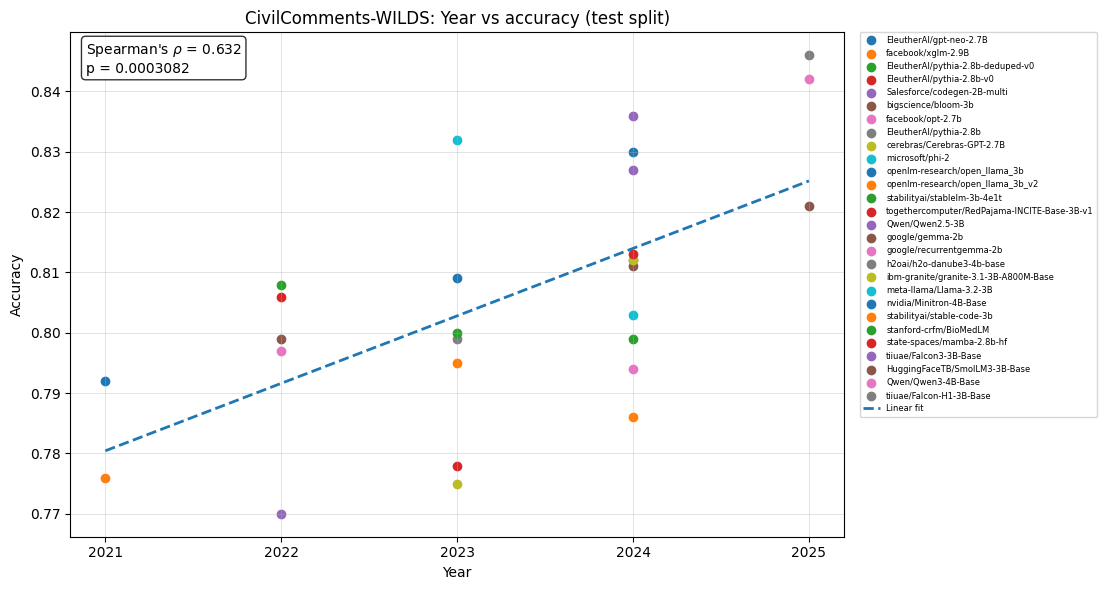

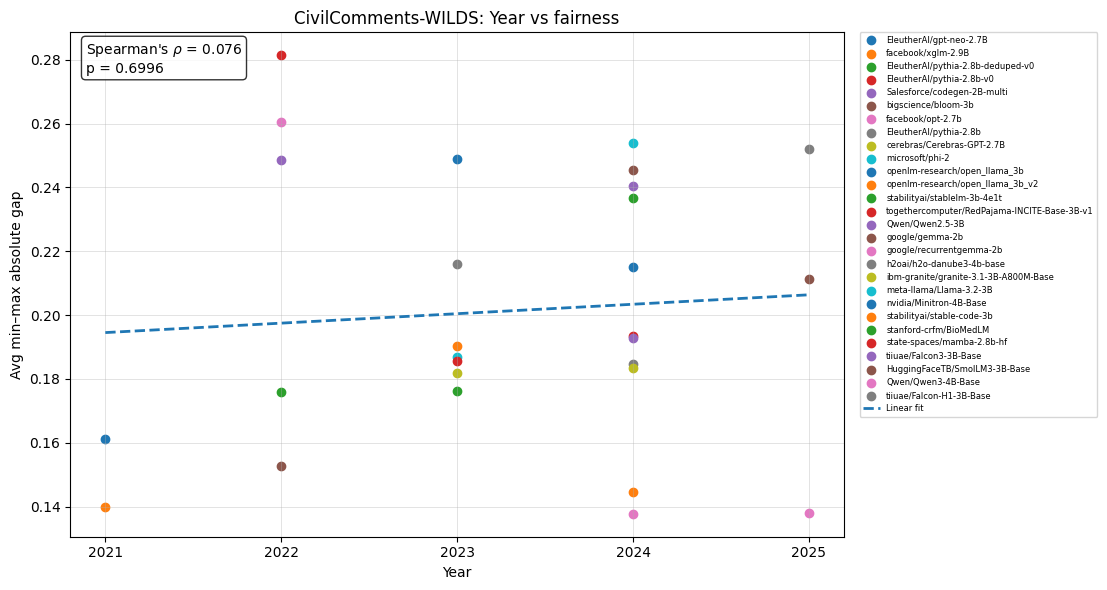

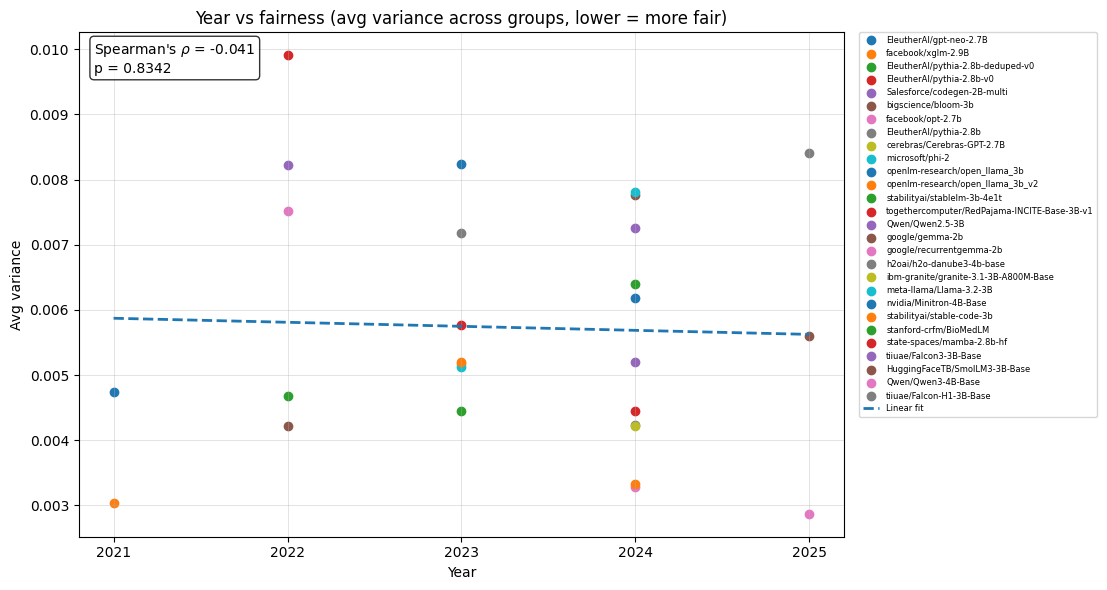

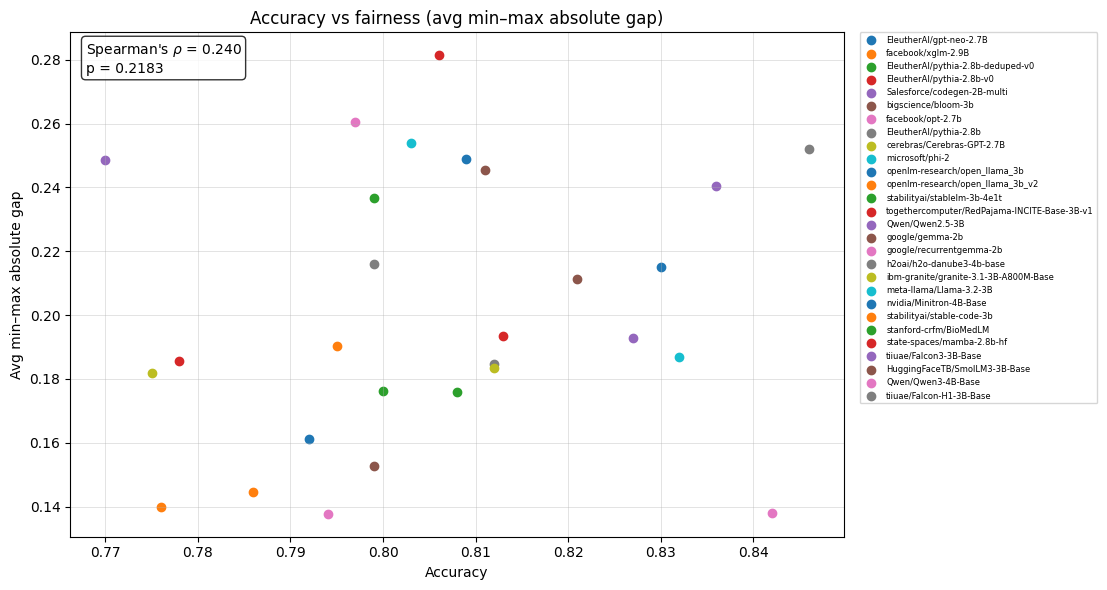

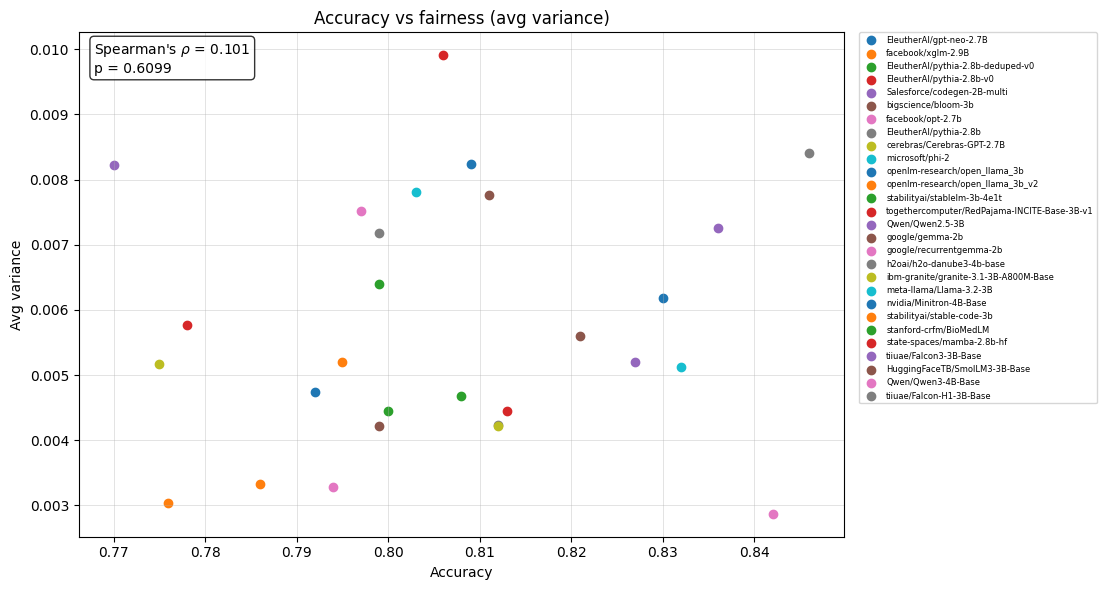

In [7]:
# helper functions for plotting

def scatter_models_legend(
    df,
    xcol,
    ycol,
    title,
    xlabel,
    ylabel,
    x_is_year=False,
    add_line=True,
    line_type="year_mean",   # "year_mean" or "fit"
    corr_method="spearman",  # "spearman" or "pearson"
    show_stats=True,
    stats_loc="inside"       # "inside" or "below"
):
    fig, ax = plt.subplots(figsize=(15, 6))

    # scatter points, one color per model
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].dropna().astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)

    # numeric data for line / correlation
    sub_num = df[[xcol, ycol]].dropna().copy()
    x_all = sub_num[xcol].astype(int).to_numpy() if x_is_year else sub_num[xcol].astype(float).to_numpy()
    y_all = sub_num[ycol].astype(float).to_numpy()

    # add line
    if add_line and len(sub_num) >= 2:
        if line_type == "year_mean" and x_is_year:
            mean_line = (
                sub_num.groupby(xcol, as_index=False)[ycol]
                .mean()
                .sort_values(xcol)
            )
            ax.plot(
                mean_line[xcol].astype(int),
                mean_line[ycol].astype(float),
                marker="o",
                linewidth=2,
                label="Year mean"
            )

        elif line_type == "fit":
            slope, intercept, _, _, _ = linregress(x_all, y_all)
            xs = np.linspace(x_all.min(), x_all.max(), 200)
            ys = intercept + slope * xs
            ax.plot(xs, ys, linestyle="--", linewidth=2, label="Linear fit")

    # correlation
    stats_text = None
    if show_stats and len(sub_num) >= 2:
        if corr_method == "spearman":
            rho, pval = spearmanr(x_all, y_all)
            stats_text = f"Spearman's $\\rho$ = {rho:.3f}\np = {pval:.4g}"
        elif corr_method == "pearson":
            rho, pval = pearsonr(x_all, y_all)
            stats_text = f"Pearson's $r$ = {rho:.3f}\np = {pval:.4g}"

    if stats_text is not None:
        if stats_loc == "inside":
            ax.text(
                0.02, 0.98,
                stats_text,
                transform=ax.transAxes,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
            )
        elif stats_loc == "below":
            fig.text(0.12, 0.02, stats_text, ha="left", va="bottom", fontsize=10)

    n_models = df["model_id"].nunique()
    fontsize = 8 if n_models <= 20 else 6

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=fontsize
    )

    if stats_loc == "below":
        fig.tight_layout(rect=[0, 0.08, 0.75, 1])
    else:
        fig.tight_layout(rect=[0, 0, 0.75, 1])

    plt.show()


# --- scatterplots ---
scatter_models_legend(df, "year", "test_acc",
                      "CivilComments-WILDS: Year vs accuracy (test split)",
                      "Year", "Accuracy",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

scatter_models_legend(df, "year", FAIR_ABS,
                      "CivilComments-WILDS: Year vs fairness", # (avg min–max absolute gap)
                      "Year", "Avg min–max absolute gap",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

scatter_models_legend(df, "year", FAIR_VAR,
                      "Year vs fairness (avg variance across groups, lower = more fair)",
                      "Year", "Avg variance",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

scatter_models_legend(df, "test_acc", FAIR_ABS,
                      "Accuracy vs fairness (avg min–max absolute gap)",
                      "Accuracy", "Avg min–max absolute gap",
                      x_is_year=False)

scatter_models_legend(df, "test_acc", FAIR_VAR,
                      "Accuracy vs fairness (avg variance)",
                      "Accuracy", "Avg variance",
                      x_is_year=False)


In [8]:
# compact tables
perf_cols = ["year","model_id","threshold_t","test_acc","test_pos_rate","test_fpr","test_fnr"]
fair_cols = ["year","model_id",
             "acc_minmax_abs","acc_minmax_rel","acc_var",
             "pos_rate_minmax_abs","pos_rate_minmax_rel","pos_rate_var",
             "fpr_minmax_abs","fpr_minmax_rel","fpr_var",
             "fnr_minmax_abs","fnr_minmax_rel","fnr_var",
             "avg_minmax_abs","avg_minmax_rel","avg_var"]

perf_tbl = df[perf_cols].copy().sort_values(["year","model_id"])
fair_tbl = df[fair_cols].copy().sort_values(["year","model_id"])

perf_tbl, fair_tbl

(    year                                      model_id  threshold_t  test_acc  \
 0   2021                       EleutherAI/gpt-neo-2.7B     0.862521     0.792   
 1   2021                            facebook/xglm-2.9B     0.651355     0.776   
 2   2022             EleutherAI/pythia-2.8b-deduped-v0     0.403567     0.808   
 3   2022                     EleutherAI/pythia-2.8b-v0     0.724870     0.806   
 4   2022                   Salesforce/codegen-2B-multi     0.675765     0.770   
 5   2022                           bigscience/bloom-3b     0.821044     0.799   
 6   2022                             facebook/opt-2.7b     0.544801     0.797   
 7   2023                        EleutherAI/pythia-2.8b     0.670608     0.799   
 8   2023                    cerebras/Cerebras-GPT-2.7B     0.875693     0.775   
 9   2023                               microsoft/phi-2     0.846958     0.832   
 10  2023                 openlm-research/open_llama_3b     0.445103     0.809   
 11  2023       

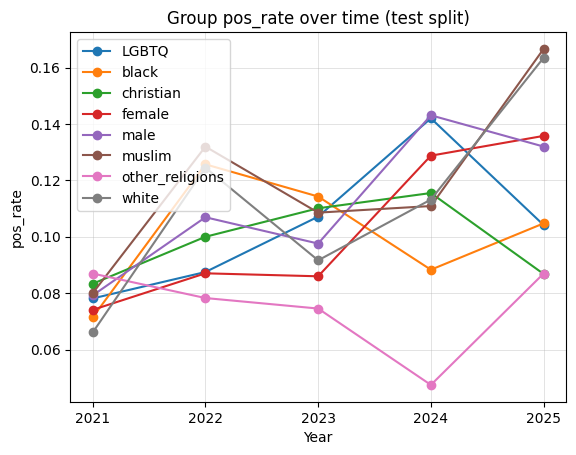

In [9]:
# group level trens for one metric
def plot_group_metric_over_time(df_groups, metric="acc"):
    wide = df_groups.pivot_table(index="year", columns="group", values=metric, aggfunc="mean").sort_index()
    plt.figure()
    for g in wide.columns:
        plt.plot(wide.index, wide[g], marker="o", label=g)
    plt.xticks(wide.index)
    plt.title(f"Group {metric} over time (test split)")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linewidth=0.5, alpha=0.5)
    plt.legend()
    plt.show()

plot_group_metric_over_time(df_groups, metric="pos_rate")

### bias plots

In [10]:
# adding crowS to df
BIAS_CSV = os.path.join(OUT_DIR, "bias_crows_pairs.csv")

df_bias = pd.read_csv(BIAS_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)

# Make sure types match (prevents silent merge miss)
df["year"] = df["year"].astype(int)
df["model_id"] = df["model_id"].astype(str)
df_bias["year"] = df_bias["year"].astype(int)
df_bias["model_id"] = df_bias["model_id"].astype(str).str.strip()

# Merge in bias
df = df.merge(df_bias[["year", "model_id", "crows_bias"]], on=["year", "model_id"], how="left")

# sanity check
print("Missing bias rows:", df["crows_bias"].isna().sum(), "/", len(df))
df[["year", "model_id", "test_acc", "crows_bias"]].head()

# one row missing bias, since I had trouble running the model

Missing bias rows: 1 / 28


,year,model_id,test_acc,crows_bias
0,2021,EleutherAI/gpt-neo-2.7B,0.792,46.816976
1,2021,facebook/xglm-2.9B,0.776,49.668435
2,2022,EleutherAI/pythia-2.8b-deduped-v0,0.808,56.299735
3,2022,EleutherAI/pythia-2.8b-v0,0.806,55.503979
4,2022,Salesforce/codegen-2B-multi,0.770,47.679045


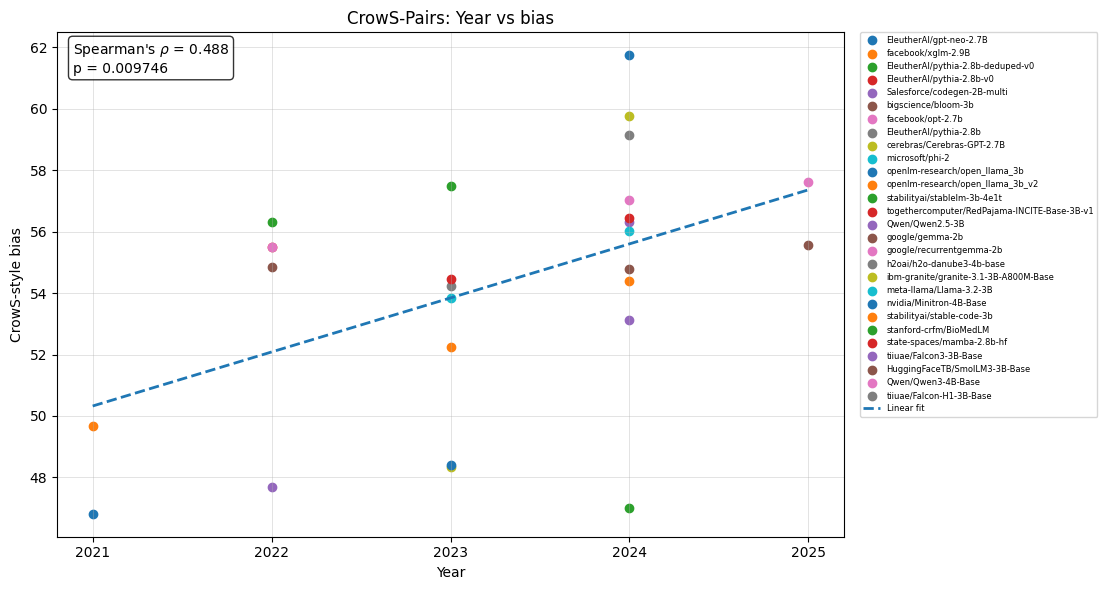

In [11]:
# Year vs bias
scatter_models_legend(df, "year", "crows_bias",
                      "CrowS-Pairs: Year vs bias", # (higher = more stereotypical preference)
                      "Year", "CrowS-style bias",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")



# it doesnt really make sense to look at accuracy fro crowS-Pairs, it is a bias benchmark where each item is a pair of sentences and you measure whether the model gives higher score to the stereotypical or less-stereotypical version
# # Accuracy vs bias
# scatter_models_legend(df, "test_acc", "crows_bias",
#                       "Accuracy vs CrowS-style bias",
#                       "Accuracy", "CrowS-style bias",
#                       x_is_year=False)

# # Year vs. accuracy
# scatter_models_legend(df, "year", "test_acc",
#                       "CrowS-Pairs: Year vs acccuracy",
#                       "Year", "Accuracy",
#                       x_is_year=True)

# how much does the yearly average change depending on which models are in that year?
- plot average for each year and add CI for the mean across models within each year

In [12]:
from IPython.display import display

In [13]:
# helper functions
def bootstrap_mean_ci(x, n_boot=5000, ci=95, seed=42):
    """
    Bootstrap CI for the mean of a 1D array.
    Returns mean, ci_low, ci_high, n, std.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n == 0:
        return pd.Series({
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        })

    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if n > 1 else 0.0

    # If only one model in a year, CI is just the point itself
    if n == 1:
        ci_low = mean
        ci_high = mean
    else:
        rng = np.random.default_rng(seed)
        boot_means = np.empty(n_boot, dtype=float)

        for b in range(n_boot):
            sample = rng.choice(x, size=n, replace=True)
            boot_means[b] = sample.mean()

        alpha = (100 - ci) / 2
        ci_low, ci_high = np.percentile(boot_means, [alpha, 100 - alpha])

    return pd.Series({
        "n": n,
        "mean": mean,
        "std": std,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high)
    })


def summarize_by_year(df, value_col, n_boot=5000, ci=95, seed=42):
    rows = []

    for year, sub in df.groupby("year"):
        stats = bootstrap_mean_ci(sub[value_col].to_numpy(), n_boot=n_boot, ci=ci, seed=seed)
        rows.append({
            "year": int(year),
            "n": stats["n"],
            "mean": stats["mean"],
            "std": stats["std"],
            "ci_low": stats["ci_low"],
            "ci_high": stats["ci_high"],
        })

    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def plot_year_mean_ci(summary_df, title, ylabel):
    """
    Plot yearly mean with CI error bars.
    """
    x = summary_df["year"].astype(int).to_numpy()
    y = summary_df["mean"].astype(float).to_numpy()
    low = summary_df["ci_low"].astype(float).to_numpy()
    high = summary_df["ci_high"].astype(float).to_numpy()

    yerr = np.vstack([y - low, high - y])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=4, color="deeppink", ecolor="deepskyblue")

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(summary_df["year"].unique()))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.show()

In [14]:
# build year-level summaries
year_acc = summarize_by_year(df, "test_acc", n_boot=5000, ci=95, seed=42)
year_fair = summarize_by_year(df, FAIR_ABS, n_boot=5000, ci=95, seed=42)
year_bias = summarize_by_year(df, "crows_bias", n_boot=5000, ci=95, seed=42)

print("Year-level mean accuracy")
display(year_acc.round(4))

print("Year-level mean fairness")
display(year_fair.round(4))

print("Year-level mean bias")
display(year_bias.round(4))

Year-level mean accuracy


,year,n,mean,std,ci_low,ci_high
0,2021,2.0,0.7840,0.0113,0.7760,0.7920
1,2022,5.0,0.7960,0.0152,0.7826,0.8054
2,2023,7.0,0.7983,0.0192,0.7861,0.8121
3,2024,11.0,0.8112,0.0154,0.8026,0.8200
4,2025,3.0,0.8363,0.0134,0.8210,0.8460


Year-level mean fairness


,year,n,mean,std,ci_low,ci_high
0,2021,2.0,0.1505,0.0149,0.1400,0.1611
1,2022,5.0,0.2238,0.0562,0.1789,0.2665
2,2023,7.0,0.1979,0.0258,0.1830,0.2172
3,2024,11.0,0.2026,0.0396,0.1798,0.2244
4,2025,3.0,0.2004,0.0579,0.1379,0.2522


Year-level mean bias


,year,n,mean,std,ci_low,ci_high
0,2021,2.0,48.2427,2.0163,46.8170,49.6684
1,2022,5.0,53.9655,3.5520,50.8090,55.8488
2,2023,7.0,52.7188,3.3495,50.3313,55.0303
3,2024,11.0,55.9742,3.8909,53.6230,58.0059
4,2025,2.0,56.5981,1.4536,55.5703,57.6260


In [15]:
# single table
year_summary = (
    year_acc[["year", "n", "mean", "ci_low", "ci_high"]]
    .rename(columns={
        "n": "n_acc",
        "mean": "acc_mean",
        "ci_low": "acc_ci_low",
        "ci_high": "acc_ci_high"
    })
    .merge(
        year_fair[["year", "n", "mean", "ci_low", "ci_high"]].rename(columns={
            "n": "n_fair",
            "mean": "fair_mean",
            "ci_low": "fair_ci_low",
            "ci_high": "fair_ci_high"
        }),
        on="year",
        how="outer"
    )
    .merge(
        year_bias[["year", "n", "mean", "ci_low", "ci_high"]].rename(columns={
            "n": "n_bias",
            "mean": "bias_mean",
            "ci_low": "bias_ci_low",
            "ci_high": "bias_ci_high"
        }),
        on="year",
        how="outer"
    )
    .sort_values("year")
    .reset_index(drop=True)
)

print("Combined year summary")
display(year_summary.round(4))

Combined year summary


,year,n_acc,acc_mean,acc_ci_low,acc_ci_high,n_fair,fair_mean,fair_ci_low,fair_ci_high,n_bias,bias_mean,bias_ci_low,bias_ci_high
0,2021,2.0,0.7840,0.7760,0.7920,2.0,0.1505,0.1400,0.1611,2.0,48.2427,46.8170,49.6684
1,2022,5.0,0.7960,0.7826,0.8054,5.0,0.2238,0.1789,0.2665,5.0,53.9655,50.8090,55.8488
2,2023,7.0,0.7983,0.7861,0.8121,7.0,0.1979,0.1830,0.2172,7.0,52.7188,50.3313,55.0303
3,2024,11.0,0.8112,0.8026,0.8200,11.0,0.2026,0.1798,0.2244,11.0,55.9742,53.6230,58.0059
4,2025,3.0,0.8363,0.8210,0.8460,3.0,0.2004,0.1379,0.2522,2.0,56.5981,55.5703,57.6260


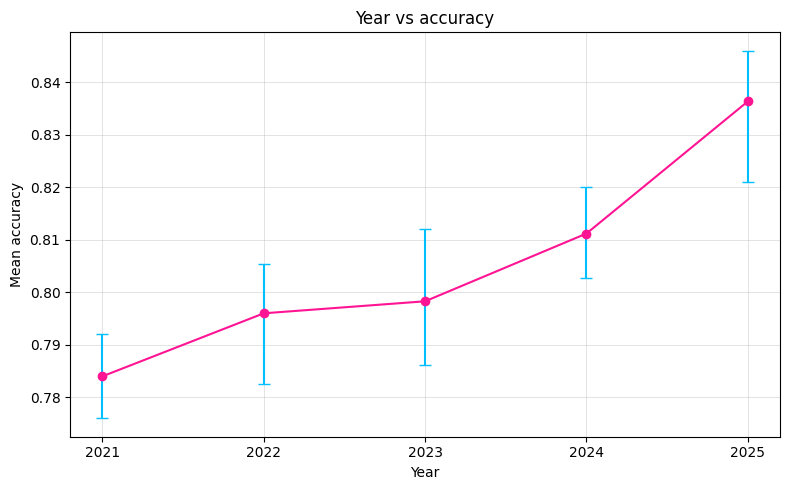

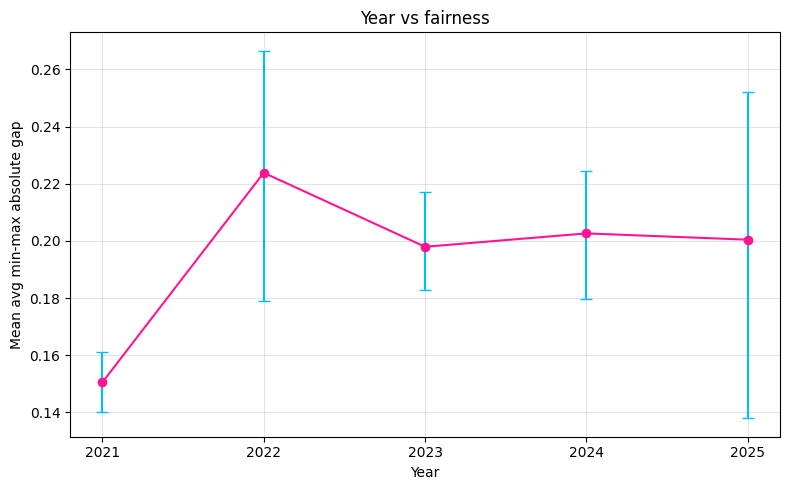

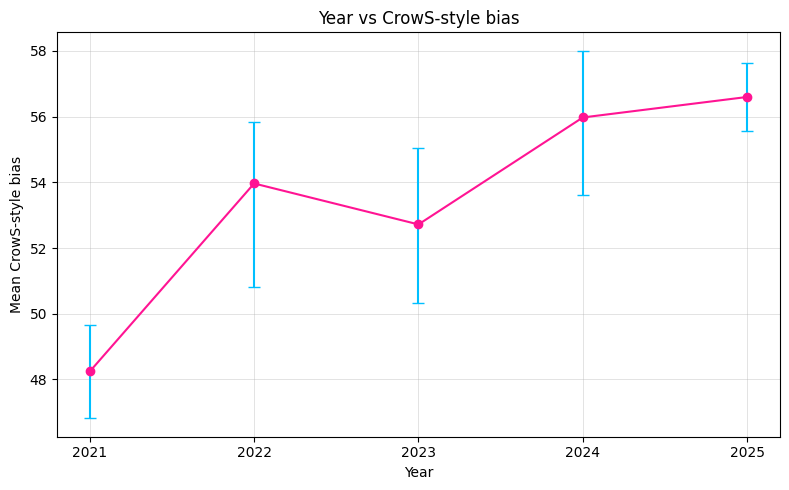

In [16]:
# plots with yearly means
plot_year_mean_ci(
    year_acc,
    title="Year vs accuracy", # (mean across models, with 95% bootstrap CI)
    ylabel="Mean accuracy"
)

plot_year_mean_ci(
    year_fair,
    title="Year vs fairness", # (mean avg min-max absolute gap, with 95% bootstrap CI)
    ylabel="Mean avg min-max absolute gap"
)

plot_year_mean_ci(
    year_bias,
    title="Year vs CrowS-style bias", # (mean across models, with 95% bootstrap CI)
    ylabel="Mean CrowS-style bias"
)

# correlation between year and each metric
using Spearman correlation because:
- year is ordinal and only takes a few balues
- we care about whether metrics generally go up or down over time
- it is less sensitive to nonlinearity and outliers (compared to Pearson correlation)
<br>
<br>
will do two different correlations:
1. model-level correlation: we correlate year with the metric across all models, which uses more data points, but since we have different number of data points for each year, some years get more weight
2. year-mean correlation: we first average within each year, then correlate year with yearly mean, but since there is few points (few years) inference is weak

In [17]:
from scipy.stats import spearmanr

In [18]:
def spearman_with_year(df, value_col):
    sub = df[["year", value_col]].dropna().copy()
    rho, pval = spearmanr(sub["year"], sub[value_col])
    return {
        "metric": value_col,
        "n": len(sub),
        "spearman_rho": rho,
        "p_value": pval
    }

# model-level correlations
corr_model_level = pd.DataFrame([
    spearman_with_year(df, "test_acc"),
    spearman_with_year(df, FAIR_ABS),
    spearman_with_year(df, "crows_bias"),
])

display(corr_model_level.round(4))

,metric,n,spearman_rho,p_value
0,test_acc,28,0.6321,0.0003
1,avg_minmax_abs,28,0.0763,0.6996
2,crows_bias,27,0.4884,0.0097


In [19]:
# year-mean correlations
corr_year_mean = pd.DataFrame([
    spearman_with_year(year_acc.rename(columns={"mean": "value"}), "value"),
    spearman_with_year(year_fair.rename(columns={"mean": "value"}), "value"),
    spearman_with_year(year_bias.rename(columns={"mean": "value"}), "value"),
])

corr_year_mean["metric"] = ["year_mean_acc", "year_mean_fairness", "year_mean_bias"]

display(corr_year_mean.round(4))

,metric,n,spearman_rho,p_value
0,year_mean_acc,5,1.0,0.0000
1,year_mean_fairness,5,0.3,0.6238
2,year_mean_bias,5,0.9,0.0374


In [20]:
# combined table
corr_tbl = pd.DataFrame([
    {
        "level": "model",
        **spearman_with_year(df, "test_acc")
    },
    {
        "level": "model",
        **spearman_with_year(df, FAIR_ABS)
    },
    {
        "level": "model",
        **spearman_with_year(df, "crows_bias")
    },
    {
        "level": "year_mean",
        **spearman_with_year(year_acc.rename(columns={"mean": "value"}), "value")
    },
    {
        "level": "year_mean",
        **spearman_with_year(year_fair.rename(columns={"mean": "value"}), "value")
    },
    {
        "level": "year_mean",
        **spearman_with_year(year_bias.rename(columns={"mean": "value"}), "value")
    },
])

corr_tbl.loc[3, "metric"] = "test_acc"
corr_tbl.loc[4, "metric"] = FAIR_ABS
corr_tbl.loc[5, "metric"] = "crows_bias"

display(corr_tbl.round(4))

,level,metric,n,spearman_rho,p_value
0,model,test_acc,28,0.6321,0.0003
1,model,avg_minmax_abs,28,0.0763,0.6996
2,model,crows_bias,27,0.4884,0.0097
3,year_mean,test_acc,5,1.0000,0.0000
4,year_mean,avg_minmax_abs,5,0.3000,0.6238
5,year_mean,crows_bias,5,0.9000,0.0374


### interpretation (not new numbers)
- model-level accruacy: rho is positive and p-values is below 0.05, so there is a fairly clear positive association between year and accuracy
    - newer models in our sample tend to have higher accuracy
- year-mean level accuracy: also positive rho and small p-value, so also strongly positive
    - the average accuracy per year also seems to rise over time
    - but based on only five years, so it looks strong but should be interpretated cautiously
<br><br>
-  model-level fairness: rhos is positive and p-value is kinda close to 0.05
    - there is a moderate positive trebnd, meaning the fairness gap tends to get larger over time
    - larger gap = worse fairness, so points towards slightly worse fairness in newer models
    - but p-value is above 0.05, so this is suggestive and not strong evidence
- year-mean level fairness: rhos is positive but p-value is high
    - yearly menas point in the same direction with worsening fairness, but with only 5 yearly points, it is far too uncertain to treat as strong evidence
results weakly suggests that fairness worsens over time
<br><br>
- model-level bias: positive rho, high p-value 
- year-mean level bias: positive rho, hihh p-value
    - both are positive, so bias may be increasing a bit over time
    - but association is weak and very uncertain
    - no convincing evidence of a time trend here

### conclusion
something like: <br>
Spearman correlations showed a clear positive association between release year and test accuracy. In contrast, fairness measure as the average min-max absolute group gap, showed a positive but weaker association with year, suggesting that fairness did not improve over time and may have worsened slightly. CrowS-Pairs bias did not exhibit a clear montonic trend across release years. 

### are bias and fairness associated?

In [21]:
# direct association with Spearman and Pearson correlation
from scipy.stats import pearsonr

sub = df[["crows_bias", FAIR_ABS]].dropna().copy()

rho_s, p_s = spearmanr(sub["crows_bias"], sub[FAIR_ABS])
rho_p, p_p = pearsonr(sub["crows_bias"], sub[FAIR_ABS])

print("Spearman:", rho_s, "p-value:", p_s)
print("Pearson:", rho_p, "p-value:", p_p)

Spearman: -0.13221374662146726 p-value: 0.5109300542730522
Pearson: -0.09058538075347831 p-value: 0.6531802326423893


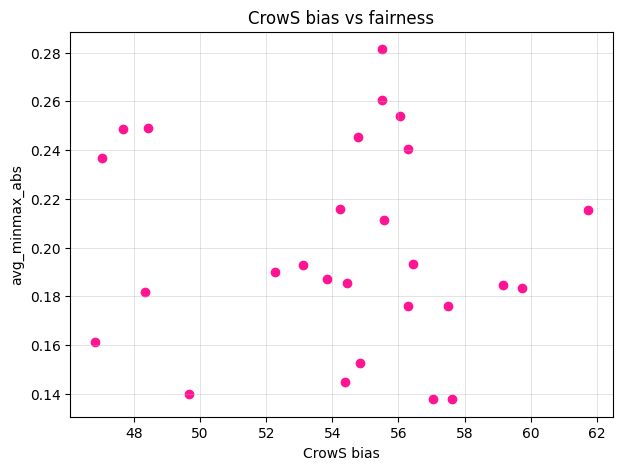

In [22]:
# visual check
plt.figure(figsize=(7,5))
plt.scatter(sub["crows_bias"], sub[FAIR_ABS], color="deeppink")
plt.xlabel("CrowS bias")
plt.ylabel(FAIR_ABS)
plt.title("CrowS bias vs fairness")
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.show()

trying to remove the shared time trend:
- if both bias and fairness drift slightly with year, thein their raw correlation may just reflect time, not a real relationship between the two constructs
- so we check association within years (or after removing year effects)

In [23]:
# among models from the same year, do the more biased ones also tend to have worse fairness??
sub = df[["year", "crows_bias", FAIR_ABS]].dropna().copy()

sub["bias_within_year"] = sub["crows_bias"] - sub.groupby("year")["crows_bias"].transform("mean")
sub["fair_within_year"] = sub[FAIR_ABS] - sub.groupby("year")[FAIR_ABS].transform("mean")

rho_within, p_within = spearmanr(sub["bias_within_year"], sub["fair_within_year"])
print("Within-year Spearman:", rho_within, "p-value:", p_within)

Within-year Spearman: -0.28850557502976104 p-value: 0.14444824580472623


In [24]:
# also trying to correlate crows_bias with all the seperate fairness commponents, to see if the avergae hides a relationship with one specific component
fairness_metrics = [
    "acc_minmax_abs",
    "pos_rate_minmax_abs",
    "fpr_minmax_abs",
    "fnr_minmax_abs",
    "avg_minmax_abs"
]

rows = []
for m in fairness_metrics:
    tmp = df[["crows_bias", m]].dropna()
    rho, p = spearmanr(tmp["crows_bias"], tmp[m])
    rows.append({"metric": m, "n": len(tmp), "spearman_rho": rho, "p_value": p})

corr_bias_fairness = pd.DataFrame(rows)
display(corr_bias_fairness.round(4))

,metric,n,spearman_rho,p_value
0,acc_minmax_abs,27,-0.3148,0.1098
1,pos_rate_minmax_abs,27,0.2269,0.2551
2,fpr_minmax_abs,27,0.0605,0.7643
3,fnr_minmax_abs,27,-0.1675,0.4037
4,avg_minmax_abs,27,-0.1322,0.5109


### interpretation
- there is no evidence for a strong association between bias and fairness
- in the overall association, both spearman and pearson are close to zero (indication no clear monotonic relationship or linear relationship)
    - models with higher CrowS bias do not systematically have worse fairness gaps
    - models with lower CrowS bias o not systematically have better fairness gap
    - and scatterplot looks diffuse, no obvious pattern
- after removing year effects, there is still no robust association (if anything there is a weak hint of a negative relation, but high p-value and not enough to conclude much)

### conclusion
something like: <br>
In this sample, CrowS-Pairs bias and group fairness disparities does not appear to be strongly related. Correlations between CrowS bias and fairness metrics were all small and non-significant, both overall and within years. This suggests that stereotype bias and group fairness capture partly distinct model properties rather than a signle shared dimension (of harm?).<br>
However, the sample size is small, so these results should be interpreted as evidence of weak association rather than proof of true statistical independence.